# Fase 3 — Entrenamiento del Random Forest

Entrenamos un `RandomForestClassifier` para predecir `aqi_class` (5 clases) a partir de features ambientales y temporales.

**Importante:** `pm25` NO se usa como feature (data leakage — el target se deriva de él).

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from src.preprocessing import AQI_LABELS

sns.set_theme(style="whitegrid")

DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

PROCESSED_CSV = DATA_DIR / "processed.csv"
MODEL_PATH = MODELS_DIR / "rf_aqi.pkl"
FEATURES_JSON = MODELS_DIR / "features.json"

print("Procesado existe?", PROCESSED_CSV.exists())

Procesado existe? True


## 1. Cargar el dataset procesado

In [2]:
df = pd.read_csv(PROCESSED_CSV, parse_dates=["datetime"])
print("Shape:", df.shape)
df.head()

Shape: (517578, 18)


,datetime,location_id,name,provider_name,lat,lon,pm25,pm10,relativehumidity,temperature,um003,hour,day,month,year,dayofweek,aqi_class,aqi_label
0,2020-04-09 16:00:00,8876,Almaty,AirNow,43.252855,76.93118,6.0,30.161375,48.295834,8.345833,1988.9375,16,9,4,2020,3,0,Buena
1,2020-04-09 17:00:00,8876,Almaty,AirNow,43.252855,76.93118,10.0,30.161375,48.295834,8.345833,1988.9375,17,9,4,2020,3,0,Buena
2,2020-04-09 18:00:00,8876,Almaty,AirNow,43.252855,76.93118,8.0,30.161375,48.295834,8.345833,1988.9375,18,9,4,2020,3,0,Buena
3,2020-04-09 19:00:00,8876,Almaty,AirNow,43.252855,76.93118,6.0,30.161375,48.295834,8.345833,1988.9375,19,9,4,2020,3,0,Buena
4,2020-04-09 20:00:00,8876,Almaty,AirNow,43.252855,76.93118,4.0,30.161375,48.295834,8.345833,1988.9375,20,9,4,2020,3,0,Buena


## 2. Definir features (X) y target (y)

Features numéricas únicamente (Random Forest no requiere escalado).
Excluimos `pm25` por data leakage.

In [3]:
FEATURE_COLS = [
    "pm10", "relativehumidity", "temperature", "um003",
    "hour", "day", "month", "year", "dayofweek",
    "lat", "lon",
]
TARGET_COL = "aqi_class"

X = df[FEATURE_COLS].astype(float)
y = df[TARGET_COL].astype(int)
print("X:", X.shape, "| y:", y.shape)
print("\nDistribución de y:")
print(y.value_counts().sort_index())

X: (517578, 11) | y: (517578,)

Distribución de y:
aqi_class
0    175205
1    212380
2     53228
3     54584
4     22181
Name: count, dtype: int64


## 3. Train / test split estratificado

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (414062, 11) | Test: (103516, 11)


## 4. Entrenamiento

⏱️ Con ~414K filas de entrenamiento, n_estimators=100 y n_jobs=-1, esto puede tardar **2-5 minutos** dependiendo de tu CPU.

**Árboles podados:** `max_depth=20` y `min_samples_leaf=50` mantienen el modelo compacto (~30-80 MB) para que quepa en Render free y pueda subirse a GitHub, con muy poca pérdida de accuracy.

In [5]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
print("Modelo entrenado ✓")

Modelo entrenado ✓


## 5. Evaluación

In [6]:
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print("\nClassification report:")
print(classification_report(
    y_test, y_pred,
    target_names=[AQI_LABELS[i] for i in sorted(AQI_LABELS)],
    digits=4,
))

Accuracy: 0.7116

Classification report:
                              precision    recall  f1-score   support

                       Buena     0.7419    0.7867    0.7637     35041
                    Moderada     0.7952    0.6122    0.6918     42476
Dañina para grupos sensibles     0.5494    0.6801    0.6078     10646
                      Dañina     0.6287    0.8159    0.7101     10917
                  Muy dañina     0.6247    0.8898    0.7341      4436

                    accuracy                         0.7116    103516
                   macro avg     0.6680    0.7569    0.7015    103516
                weighted avg     0.7270    0.7116    0.7112    103516



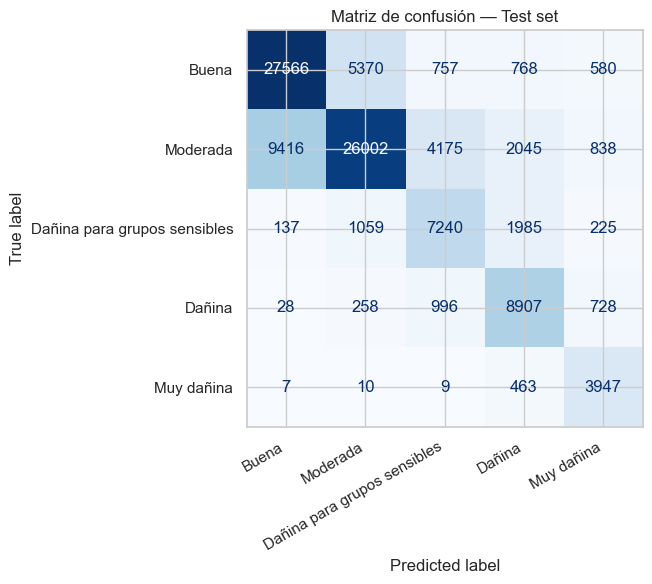

In [7]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
labels = [AQI_LABELS[i] for i in sorted(AQI_LABELS)]
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=labels).plot(
    ax=ax, cmap="Blues", colorbar=False, values_format="d",
)
ax.set_title("Matriz de confusión — Test set")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

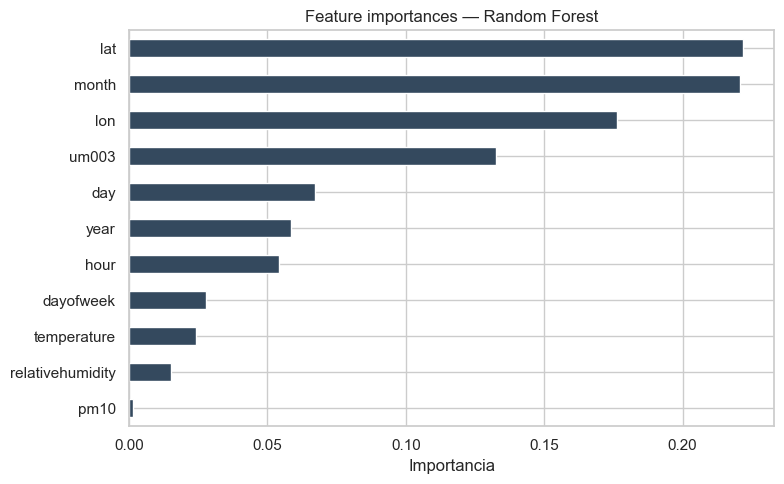

lat                 0.221959
month               0.220761
lon                 0.176173
um003               0.132732
day                 0.067072
year                0.058536
hour                0.054173
dayofweek           0.027891
temperature         0.024231
relativehumidity    0.015128
pm10                0.001344
dtype: float64

In [8]:
# Importancia de features
importances = (
    pd.Series(rf.feature_importances_, index=FEATURE_COLS)
    .sort_values(ascending=True)
)
fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind="barh", color="#34495e", ax=ax)
ax.set_title("Feature importances — Random Forest")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.show()
importances.sort_values(ascending=False)

## 6. Guardar modelo y metadata

- `models/rf_aqi.pkl`: el modelo serializado.
- `models/features.json`: lista de features esperadas, medianas para imputación en la API, y labels de clases.

In [9]:
joblib.dump(rf, MODEL_PATH)
print("Modelo guardado:", MODEL_PATH)
print("Tamaño:", round(MODEL_PATH.stat().st_size / 1024 / 1024, 2), "MB")

Modelo guardado: C:\Users\esteb\Desktop\TF CLOUD\TF-Cloud\models\rf_aqi.pkl
Tamaño: 58.54 MB


In [10]:
# Recalcular medianas sobre el dataset procesado (mismas que en la Fase 2)
MEDIAN_COLS = ["pm10", "relativehumidity", "temperature", "um003"]
medians = {col: float(df[col].median()) for col in MEDIAN_COLS}

metadata = {
    "feature_names": FEATURE_COLS,
    "target": TARGET_COL,
    "class_labels": {str(k): v for k, v in AQI_LABELS.items()},
    "medians": medians,
    "model_type": "RandomForestClassifier",
    "params": {
        "n_estimators": 100,
        "max_depth": 20,
        "min_samples_leaf": 50,
        "class_weight": "balanced",
        "random_state": 42,
    },
    "metrics": {
        "accuracy_test": float(acc),
    },
    "n_train": int(len(X_train)),
    "n_test": int(len(X_test)),
}

with open(FEATURES_JSON, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("Metadata guardada:", FEATURES_JSON)
print(json.dumps(metadata, indent=2, ensure_ascii=False))

Metadata guardada: C:\Users\esteb\Desktop\TF CLOUD\TF-Cloud\models\features.json
{
  "feature_names": [
    "pm10",
    "relativehumidity",
    "temperature",
    "um003",
    "hour",
    "day",
    "month",
    "year",
    "dayofweek",
    "lat",
    "lon"
  ],
  "target": "aqi_class",
  "class_labels": {
    "0": "Buena",
    "1": "Moderada",
    "2": "Dañina para grupos sensibles",
    "3": "Dañina",
    "4": "Muy dañina"
  },
  "medians": {
    "pm10": 30.161374886830647,
    "relativehumidity": 48.29583366711934,
    "temperature": 8.345833470424015,
    "um003": 1988.9375
  },
  "model_type": "RandomForestClassifier",
  "params": {
    "n_estimators": 100,
    "max_depth": 20,
    "min_samples_leaf": 50,
    "class_weight": "balanced",
    "random_state": 42
  },
  "metrics": {
    "accuracy_test": 0.71160013910893
  },
  "n_train": 414062,
  "n_test": 103516
}


## 7. Smoke test del modelo guardado

Verificamos que el `.pkl` se puede cargar y predecir correctamente, simulando lo que hará la API en la Fase 5.

In [11]:
loaded = joblib.load(MODEL_PATH)
with open(FEATURES_JSON, encoding="utf-8") as f:
    meta = json.load(f)

# Ejemplo: condiciones típicas de invierno en Almaty (~enero, mediodía)
sample = {
    "pm10": 35.0,
    "relativehumidity": 70.0,
    "temperature": -5.0,
    "um003": 2500.0,
    "hour": 12,
    "day": 15,
    "month": 1,
    "year": 2025,
    "dayofweek": 2,
    "lat": 43.25,
    "lon": 76.93,
}
x_sample = pd.DataFrame([[sample[c] for c in meta["feature_names"]]], columns=meta["feature_names"])
pred_class = int(loaded.predict(x_sample)[0])
proba = loaded.predict_proba(x_sample)[0]

print("Input:", sample)
print(f"\nPredicción → clase {pred_class} ({meta['class_labels'][str(pred_class)]})")
print("\nProbabilidades por clase:")
for i, p in enumerate(proba):
    print(f"  {i} {meta['class_labels'][str(i)]:<30s} {p:.4f}")

Input: {'pm10': 35.0, 'relativehumidity': 70.0, 'temperature': -5.0, 'um003': 2500.0, 'hour': 12, 'day': 15, 'month': 1, 'year': 2025, 'dayofweek': 2, 'lat': 43.25, 'lon': 76.93}

Predicción → clase 3 (Dañina)

Probabilidades por clase:
  0 Buena                          0.0076
  1 Moderada                       0.2174
  2 Dañina para grupos sensibles   0.1395
  3 Dañina                         0.5728
  4 Muy dañina                     0.0627
